In [1]:
!pip3 install html5lib
!pip3 install lxml

# Criando nomes

In [2]:
import pandas as pd

In [3]:
nomes_f = pd.read_json('https://guilhermeonrails.github.io/nomes_ibge/nomes-f.json')
nomes_m = pd.read_json('https://guilhermeonrails.github.io/nomes_ibge/nomes-m.json')

In [4]:
nomes_f.sample(5)

,nome,regiao,freq,rank,sexo
99,DENISE,0,168666,100,F
150,GIOVANA,0,106738,151,F
102,MARILENE,0,163944,103,F
56,SUELI,0,243899,57,F
90,ANDRESSA,0,184933,91,F


In [5]:
print("Quantidade de nomes: " + str(len(nomes_f) + len(nomes_m)))

Quantidade de nomes: 400


In [6]:
frames = [nomes_f, nomes_m]

In [7]:
pd.concat(frames)['nome'].to_frame()

,nome
0,MARIA
1,ANA
2,FRANCISCA
3,ANTONIA
4,ADRIANA
...,...
195,WALTER
196,ARLINDO
197,MICHAEL
198,ALVARO


In [8]:
nomes = pd.concat(frames)['nome'].to_frame()

In [9]:
nomes.sample(5)

,nome
157,JAIME
93,ADILSON
115,MILTON
106,ARTUR
98,GILSON


# Incluindo ID dos alunos

In [10]:
import numpy as np
np.random.seed(123)

In [11]:
total_alunos = len(nomes)
total_alunos

400

In [12]:
nomes.sample(3)

,nome
34,SEBASTIAO
42,MARLENE
103,MAICON


In [13]:
nomes["id_aluno"] =  np.random.permutation(total_alunos) + 1

In [14]:
dominios = ['@dominiodoemmail.com.br', '@servicodoemail.com']

In [15]:
dominios = ['@dominiodoemmail.com.br', '@servicodoemail.com']
nomes['dominio'] = np.random.choice(dominios, total_alunos)

In [16]:
nomes['email'] = nomes.nome.str.cat(nomes.dominio).str.lower()

In [17]:
nomes

,nome,id_aluno,dominio,email
0,MARIA,189,@dominiodoemmail.com.br,maria@dominiodoemmail.com.br
1,ANA,58,@servicodoemail.com,ana@servicodoemail.com
2,FRANCISCA,204,@servicodoemail.com,francisca@servicodoemail.com
3,ANTONIA,383,@dominiodoemmail.com.br,antonia@dominiodoemmail.com.br
4,ADRIANA,231,@servicodoemail.com,adriana@servicodoemail.com
...,...,...,...,...
195,WALTER,9,@dominiodoemmail.com.br,walter@dominiodoemmail.com.br
196,ARLINDO,378,@servicodoemail.com,arlindo@servicodoemail.com
197,MICHAEL,50,@dominiodoemmail.com.br,michael@dominiodoemmail.com.br
198,ALVARO,244,@dominiodoemmail.com.br,alvaro@dominiodoemmail.com.br


# Criando Tabela Cursos

In [18]:
import html5lib

In [19]:
url = 'http://tabela-cursos.herokuapp.com/index.html'
cursos = pd.read_html(url)
cursos

[                          Nome do curso
 0                 Lógica de programação
 1                         Java para Web
 2                           C# para Web
 3                         Ruby on Rails
 4                      Cursos de Python
 5                         PHP com MySql
 6                         .NET para web
 7            Novas integrações com Java
 8                          TDD com Java
 9                   Código limpo com C#
 10  Preparatório para certificação Java
 11                      Hardware básico
 12                Persistência com .NET
 13                  Desenvolvendo jogos
 14                     Análise de dados
 15                   Estatística básica
 16                  Internet das coisas
 17                Programação funcional
 18                Boas práticas em Java
 19          Orientação objetos com Java]

In [20]:
type(cursos)

list

In [21]:
cursos = cursos[0]

In [22]:
type(cursos)

pandas.core.frame.DataFrame

In [23]:
cursos

,Nome do curso
0,Lógica de programação
1,Java para Web
2,C# para Web
3,Ruby on Rails
4,Cursos de Python
5,PHP com MySql
6,.NET para web
7,Novas integrações com Java
8,TDD com Java
9,Código limpo com C#


# Alterando Index do curso

In [24]:
cursos = cursos.rename(columns={'Nome do curso': 'nome_do_curso'})
cursos.head(2)

,nome_do_curso
0,Lógica de programação
1,Java para Web


In [25]:
cursos['id'] = cursos.index + 1
cursos.head()

,nome_do_curso,id
0,Lógica de programação,1
1,Java para Web,2
2,C# para Web,3
3,Ruby on Rails,4
4,Cursos de Python,5


In [26]:
cursos = cursos.set_index('id')
cursos.head()

,nome_do_curso
id,
1,Lógica de programação
2,Java para Web
3,C# para Web
4,Ruby on Rails
5,Cursos de Python


# Matriculando os alunos nos cursos

In [27]:
nomes['matriculas'] = np.random.exponential(size=total_alunos).astype(int)
nomes.sample(5)

,nome,id_aluno,dominio,email,matriculas
193,LUCILENE,120,@dominiodoemmail.com.br,lucilene@dominiodoemmail.com.br,0
187,ELTON,82,@dominiodoemmail.com.br,elton@dominiodoemmail.com.br,0
32,MARCIO,344,@dominiodoemmail.com.br,marcio@dominiodoemmail.com.br,0
113,VICENTE,27,@servicodoemail.com,vicente@servicodoemail.com,1
199,NILZA,339,@dominiodoemmail.com.br,nilza@dominiodoemmail.com.br,0


In [28]:
nomes['matriculas'] = np.ceil(np.random.exponential(size=total_alunos)).astype(int)
nomes.sample(5)

,nome,id_aluno,dominio,email,matriculas
9,ALINE,268,@dominiodoemmail.com.br,aline@dominiodoemmail.com.br,1
165,EUNICE,313,@servicodoemail.com,eunice@servicodoemail.com,1
98,THAIS,12,@servicodoemail.com,thais@servicodoemail.com,1
17,FELIPE,100,@servicodoemail.com,felipe@servicodoemail.com,1
47,JULIO,21,@dominiodoemmail.com.br,julio@dominiodoemmail.com.br,3


In [29]:
nomes['matriculas'] = np.ceil(np.random.exponential(size=total_alunos) * 1.5).astype(int)
nomes.sample(5)

,nome,id_aluno,dominio,email,matriculas
167,ANGELO,180,@servicodoemail.com,angelo@servicodoemail.com,4
150,GIOVANA,399,@servicodoemail.com,giovana@servicodoemail.com,2
134,ALBERTO,7,@dominiodoemmail.com.br,alberto@dominiodoemmail.com.br,6
155,EMANUEL,33,@servicodoemail.com,emanuel@servicodoemail.com,2
151,SEVERINA,316,@dominiodoemmail.com.br,severina@dominiodoemmail.com.br,1


In [30]:
nomes.matriculas.describe()

count    400.000000
mean       2.152500
std        1.586043
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        9.000000
Name: matriculas, dtype: float64

In [31]:
import seaborn as sns

<AxesSubplot:xlabel='matriculas'>

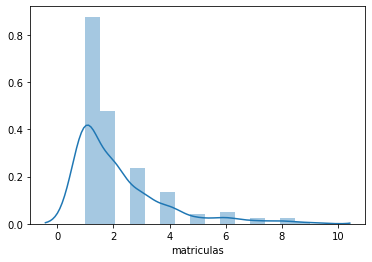

In [32]:
sns.distplot(nomes.matriculas)

In [33]:
nomes.matriculas.value_counts()

1    187
2    102
3     50
4     29
6     11
5      9
8      5
7      5
9      2
Name: matriculas, dtype: int64

# Selecionando Cursos

In [34]:
nomes.sample(5)

,nome,id_aluno,dominio,email,matriculas
15,LETICIA,90,@dominiodoemmail.com.br,leticia@dominiodoemmail.com.br,2
187,NAIARA,65,@dominiodoemmail.com.br,naiara@dominiodoemmail.com.br,1
104,EVA,314,@servicodoemail.com,eva@servicodoemail.com,1
70,JOAQUIM,182,@servicodoemail.com,joaquim@servicodoemail.com,1
188,POLIANA,166,@servicodoemail.com,poliana@servicodoemail.com,4


In [35]:
todas_matriculas = []
x = np.random.rand(20)
prob = x / sum(x)

In [36]:
for index, row in nomes.iterrows():
  id = row.id_aluno
  matriculas = row.matriculas
  for i in range(matriculas):
    mat = [id, np.random.choice(cursos.index, p = prob)]
    todas_matriculas.append(mat)

matriculas = pd.DataFrame(todas_matriculas, columns = ['id_aluno', 'id_curso'])
matriculas.head(5)

,id_aluno,id_curso
0,189,18
1,189,14
2,58,19
3,204,2
4,204,9


In [37]:
matriculas.groupby('id_curso').count().join(cursos['nome_do_curso'])

,id_aluno,nome_do_curso
id_curso,,
1,72,Lógica de programação
2,62,Java para Web
3,4,C# para Web
4,33,Ruby on Rails
5,64,Cursos de Python
6,23,PHP com MySql
7,79,.NET para web
8,33,Novas integrações com Java
9,43,TDD com Java


In [38]:
matriculas.groupby('id_curso').count().join(cursos['nome_do_curso']).rename(columns={'id_aluno':'quantidade_de_alunos'})

,quantidade_de_alunos,nome_do_curso
id_curso,,
1,72,Lógica de programação
2,62,Java para Web
3,4,C# para Web
4,33,Ruby on Rails
5,64,Cursos de Python
6,23,PHP com MySql
7,79,.NET para web
8,33,Novas integrações com Java
9,43,TDD com Java


In [39]:
nomes.sample(3)

,nome,id_aluno,dominio,email,matriculas
192,ZILDA,113,@servicodoemail.com,zilda@servicodoemail.com,2
46,LUCIANO,111,@dominiodoemmail.com.br,luciano@dominiodoemmail.com.br,3
111,TAMIRES,155,@dominiodoemmail.com.br,tamires@dominiodoemmail.com.br,1


In [40]:
cursos.head()

,nome_do_curso
id,
1,Lógica de programação
2,Java para Web
3,C# para Web
4,Ruby on Rails
5,Cursos de Python


In [41]:
matriculas.head()

,id_aluno,id_curso
0,189,18
1,189,14
2,58,19
3,204,2
4,204,9


In [42]:
matriculas_por_curso = matriculas.groupby('id_curso').count().join(cursos['nome_do_curso']).rename(columns={'id_aluno':'quantidade_de_alunos'})

In [43]:
matriculas_por_curso.head()

,quantidade_de_alunos,nome_do_curso
id_curso,,
1,72,Lógica de programação
2,62,Java para Web
3,4,C# para Web
4,33,Ruby on Rails
5,64,Cursos de Python


# Saída em diferentes formatos

In [44]:
matriculas_por_curso.to_csv('matriculas_por_curso.csv', index=False)

In [45]:
pd.read_csv('matriculas_por_curso.csv')

,quantidade_de_alunos,nome_do_curso
0,72,Lógica de programação
1,62,Java para Web
2,4,C# para Web
3,33,Ruby on Rails
4,64,Cursos de Python
5,23,PHP com MySql
6,79,.NET para web
7,33,Novas integrações com Java
8,43,TDD com Java
9,34,Código limpo com C#


In [46]:
matriculas_json = matriculas_por_curso.to_json()
matriculas_json

'{"quantidade_de_alunos":{"1":72,"2":62,"3":4,"4":33,"5":64,"6":23,"7":79,"8":33,"9":43,"10":34,"11":63,"12":45,"13":66,"14":85,"15":24,"16":11,"17":26,"18":55,"19":18,"20":21},"nome_do_curso":{"1":"L\\u00f3gica de programa\\u00e7\\u00e3o","2":"Java para Web","3":"C# para Web","4":"Ruby on Rails","5":"Cursos de Python","6":"PHP com MySql","7":".NET para web","8":"Novas integra\\u00e7\\u00f5es com Java","9":"TDD com Java","10":"C\\u00f3digo limpo com C#","11":"Preparat\\u00f3rio para certifica\\u00e7\\u00e3o Java","12":"Hardware b\\u00e1sico","13":"Persist\\u00eancia com .NET","14":"Desenvolvendo jogos","15":"An\\u00e1lise de dados","16":"Estat\\u00edstica b\\u00e1sica","17":"Internet das coisas","18":"Programa\\u00e7\\u00e3o funcional","19":"Boas pr\\u00e1ticas em Java","20":"Orienta\\u00e7\\u00e3o objetos com Java"}}'

In [47]:
matriculas_html = matriculas_por_curso.to_html()
matriculas_html

'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th></th>\n      <th>quantidade_de_alunos</th>\n      <th>nome_do_curso</th>\n    </tr>\n    <tr>\n      <th>id_curso</th>\n      <th></th>\n      <th></th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <th>1</th>\n      <td>72</td>\n      <td>Lógica de programação</td>\n    </tr>\n    <tr>\n      <th>2</th>\n      <td>62</td>\n      <td>Java para Web</td>\n    </tr>\n    <tr>\n      <th>3</th>\n      <td>4</td>\n      <td>C# para Web</td>\n    </tr>\n    <tr>\n      <th>4</th>\n      <td>33</td>\n      <td>Ruby on Rails</td>\n    </tr>\n    <tr>\n      <th>5</th>\n      <td>64</td>\n      <td>Cursos de Python</td>\n    </tr>\n    <tr>\n      <th>6</th>\n      <td>23</td>\n      <td>PHP com MySql</td>\n    </tr>\n    <tr>\n      <th>7</th>\n      <td>79</td>\n      <td>.NET para web</td>\n    </tr>\n    <tr>\n      <th>8</th>\n      <td>33</td>\n      <td>Novas integrações com Java</td>\n 

In [48]:
print(matriculas_html)

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>quantidade_de_alunos</th>
      <th>nome_do_curso</th>
    </tr>
    <tr>
      <th>id_curso</th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>1</th>
      <td>72</td>
      <td>Lógica de programação</td>
    </tr>
    <tr>
      <th>2</th>
      <td>62</td>
      <td>Java para Web</td>
    </tr>
    <tr>
      <th>3</th>
      <td>4</td>
      <td>C# para Web</td>
    </tr>
    <tr>
      <th>4</th>
      <td>33</td>
      <td>Ruby on Rails</td>
    </tr>
    <tr>
      <th>5</th>
      <td>64</td>
      <td>Cursos de Python</td>
    </tr>
    <tr>
      <th>6</th>
      <td>23</td>
      <td>PHP com MySql</td>
    </tr>
    <tr>
      <th>7</th>
      <td>79</td>
      <td>.NET para web</td>
    </tr>
    <tr>
      <th>8</th>
      <td>33</td>
      <td>Novas integrações com Java</td>
    </tr>
    <tr>
      <th>9</th>
      <td>43</td>
 

# Criando banco de dados SQL

In [49]:
!pip3 install sqlalchemy

In [50]:
from sqlalchemy import create_engine, MetaData, Table

In [51]:
engine = create_engine('sqlite:///:memory:')

In [52]:
type(engine)

sqlalchemy.engine.base.Engine

In [53]:
matriculas_por_curso.to_sql('matriculas', engine)

20

In [54]:
print(engine.table_names())

['matriculas']


C:\Users\DionizVF\AppData\Local\Temp\ipykernel_19196\1043810782.py:1: SADeprecationWarning: The Engine.table_names() method is deprecated and will be removed in a future release.  Please refer to Inspector.get_table_names(). (deprecated since: 1.4)
  print(engine.table_names())


# Buscando banco do SQL

In [55]:
query = 'select * from matriculas where quantidade_de_alunos < 20'

In [56]:
pd.read_sql(query, engine)

,id_curso,quantidade_de_alunos,nome_do_curso
0,3,4,C# para Web
1,16,11,Estatística básica
2,19,18,Boas práticas em Java


In [57]:
pd.read_sql_table('matriculas', engine, columns=['nome_do_curso', 'quantidade_de_alunos'])

,nome_do_curso,quantidade_de_alunos
0,Lógica de programação,72
1,Java para Web,62
2,C# para Web,4
3,Ruby on Rails,33
4,Cursos de Python,64
5,PHP com MySql,23
6,.NET para web,79
7,Novas integrações com Java,33
8,TDD com Java,43
9,Código limpo com C#,34


In [58]:
muitas_matriculas = pd.read_sql_table('matriculas', engine, columns=['nome_do_curso', 'quantidade_de_alunos'])

In [59]:
muitas_matriculas.query('quantidade_de_alunos > 60')

,nome_do_curso,quantidade_de_alunos
0,Lógica de programação,72
1,Java para Web,62
4,Cursos de Python,64
6,.NET para web,79
10,Preparatório para certificação Java,63
12,Persistência com .NET,66
13,Desenvolvendo jogos,85


In [60]:
muitas_matriculas = muitas_matriculas.query('quantidade_de_alunos > 80')
muitas_matriculas

,nome_do_curso,quantidade_de_alunos
13,Desenvolvendo jogos,85


In [61]:
print(engine.table_names())

['matriculas']


C:\Users\DionizVF\AppData\Local\Temp\ipykernel_19196\1043810782.py:1: SADeprecationWarning: The Engine.table_names() method is deprecated and will be removed in a future release.  Please refer to Inspector.get_table_names(). (deprecated since: 1.4)
  print(engine.table_names())


In [62]:
from sqlalchemy import create_engine, MetaData, Table, inspect # adicionando o método inspect

engine = create_engine('sqlite:///:memory:')
engine
type(engine)

matriculas_por_curso.to_sql('matriculas', engine)

inspector = inspect(engine) # criando um Inspector object
print(inspector.get_table_names()) # Exibindo as tabelas com o inspecto

['matriculas']


# Escrevendo no banco

In [63]:
muitas_matriculas.to_sql('muitas_matriculas', con=engine)

1

In [64]:
print(engine.table_names())

['matriculas', 'muitas_matriculas']


C:\Users\DionizVF\AppData\Local\Temp\ipykernel_19196\1043810782.py:1: SADeprecationWarning: The Engine.table_names() method is deprecated and will be removed in a future release.  Please refer to Inspector.get_table_names(). (deprecated since: 1.4)
  print(engine.table_names())


# Nome dos alunos da proxima turma

In [65]:
matriculas_por_curso.head()

,quantidade_de_alunos,nome_do_curso
id_curso,,
1,72,Lógica de programação
2,62,Java para Web
3,4,C# para Web
4,33,Ruby on Rails
5,64,Cursos de Python


In [66]:
matriculas.head()

,id_aluno,id_curso
0,189,18
1,189,14
2,58,19
3,204,2
4,204,9


In [67]:
id_curso = 16
proxima_turma = matriculas.query("id_curso == {}".format(id_curso))

In [68]:
proxima_turma.head()

,id_aluno,id_curso
181,216,16
185,220,16
193,274,16
214,361,16
308,97,16


In [69]:
nomes.sample(3)

,nome,id_aluno,dominio,email,matriculas
80,TAIS,163,@dominiodoemmail.com.br,tais@dominiodoemmail.com.br,2
99,DENISE,253,@servicodoemail.com,denise@servicodoemail.com,1
27,GUILHERME,125,@dominiodoemmail.com.br,guilherme@dominiodoemmail.com.br,1


In [70]:
proxima_turma.set_index('id_aluno').join(nomes.set_index('id_aluno'))

,id_curso,nome,dominio,email,matriculas
id_aluno,,,,,
216,16,FATIMA,@servicodoemail.com,fatima@servicodoemail.com,1
220,16,HELENA,@dominiodoemmail.com.br,helena@dominiodoemmail.com.br,7
274,16,ALICE,@servicodoemail.com,alice@servicodoemail.com,4
361,16,ROSELI,@dominiodoemmail.com.br,roseli@dominiodoemmail.com.br,6
97,16,SAMARA,@servicodoemail.com,samara@servicodoemail.com,3
99,16,RAIANE,@servicodoemail.com,raiane@servicodoemail.com,5
341,16,GERALDA,@servicodoemail.com,geralda@servicodoemail.com,6
27,16,VICENTE,@servicodoemail.com,vicente@servicodoemail.com,1
7,16,ALBERTO,@dominiodoemmail.com.br,alberto@dominiodoemmail.com.br,6


In [71]:
proxima_turma.set_index('id_aluno').join(nomes.set_index('id_aluno'))['nome']

id_aluno
216     FATIMA
220     HELENA
274      ALICE
361     ROSELI
97      SAMARA
99      RAIANE
341    GERALDA
27     VICENTE
7      ALBERTO
30      DAMIAO
244     ALVARO
Name: nome, dtype: object

In [72]:
proxima_turma = proxima_turma.set_index('id_aluno').join(nomes.set_index('id_aluno'))['nome'].to_frame()

In [73]:
nome_curso = cursos.loc[id_curso]
nome_curso

nome_do_curso    Estatística básica
Name: 16, dtype: object

In [74]:
nome_curso = nome_curso.nome_do_curso
nome_curso

'Estatística básica'

In [75]:
proxima_turma.rename(columns = {'nome':'Alunos do curso de {}'.format(nome_curso)})

,Alunos do curso de Estatística básica
id_aluno,
216,FATIMA
220,HELENA
274,ALICE
361,ROSELI
97,SAMARA
99,RAIANE
341,GERALDA
27,VICENTE
7,ALBERTO


In [76]:
proxima_turma = proxima_turma.rename(columns = {'nome':'Alunos do curso de {}'.format(nome_curso)})

# Excel 

In [77]:
proxima_turma.to_excel('proxima_turma.xlsx', index = False)

In [78]:
pd.read_excel('proxima_turma.xlsx')

,Alunos do curso de Estatística básica
0,FATIMA
1,HELENA
2,ALICE
3,ROSELI
4,SAMARA
5,RAIANE
6,GERALDA
7,VICENTE
8,ALBERTO
9,DAMIAO
